# Missionary and the Cannibal problem

Implement the missionaries and cannibal problem of AIMA. Problem has equla amount missionaries and caanibals which need to be transported to opposite side of the river respecting set constrainst.

## Problem description



State: Count of missionaries and cannibals on ech of the shores. Position of the boat
- ML​: Number of missionaries on the left bank
- CL: Number of cannibals on the left bank
- MR​: Number of missionaries on the right bank
- CR​: Number of cannibals on the right bank
- B: Position of the boat (L for left, R for right)
  
Initial State: all the M and C on left shore. Boat on left shore
- (3,3,0,0,L)

Goal state: All the M and C on right shore
- (0,0,3,3,R) 

State Constraints:
- ML ≥ 0, CL ≥ 0, MR ≥ 0, CR ≥0 M_L 
- On each bank: if missionaries > 0, then missionaries ≥ cannibals:
    - (ML=0 or ML ≥ CL) and (MR=0 or MR ≥ CR)

Actions Function:

Actions(state) returns all valid moves from the current state:
- Boat can carry 1 or 2 people.
- Possible combinations:
    - (2 missionaries)
    - (2 cannibals)
    - (1 missionary + 1 cannibal)
    - (1 missionary)
    - (1 cannibal)

Transition Model:

- Result(state, action) → new state after applying action
    - Update counts based on boat direction.
    - Validate constraints.

Goal Test
- GoalTest(state):
    - state=(0,0,3,3,R)state = (0, 0, 3, 3, R)


### Imports

## Problem Implementation

In [19]:
# Import required modules

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().resolve().parent.parent))

from search4e import Problem
from search4e import uniform_cost_search, greedy_bfs, weighted_astar_search
from search4e import breadth_first_search, report
import matplotlib.pyplot as plt

In [7]:
class MissionaryProblem(Problem):
    """
    The Missionaries and Cannibals problem.
    
    Three missionaries and three cannibals must cross a river using a boat
    that can carry at most two people. At no point can cannibals outnumber
    missionaries on either bank (unless there are no missionaries on that bank).
    
    State representation: (M_L, C_L, M_R, C_R, B)
        M_L: Number of missionaries on the left bank
        C_L: Number of cannibals on the left bank
        M_R: Number of missionaries on the right bank
        C_R: Number of cannibals on the right bank
        B: Boat position ('L' for left bank, 'R' for right bank)
    
    Actions: (m, c) tuples representing number of missionaries and cannibals
        to move in the boat. Possible combinations:
        (2,0) - 2 missionaries
        (0,2) - 2 cannibals
        (1,1) - 1 missionary + 1 cannibal
        (1,0) - 1 missionary
        (0,1) - 1 cannibal
    """
    
    def __init__(self, initial=(3, 3, 0, 0, 'L'), goal=(0, 0, 3, 3, 'R'), **kwds):
        """
        Initialize the Missionaries and Cannibals problem.
        
        Args:
            initial: Starting state (default: all on left bank)
            goal: Goal state (default: all on right bank)
        """
        super().__init__(initial=initial, goal=goal, **kwds)
    
    def actions(self, state):
        """
        Return only valid boat moves from the current state.
        Filters out actions that would lead to invalid states.
        """
        valid_actions = []
        for action in [(2, 0), (0, 2), (1, 1), (1, 0), (0, 1)]:
            # Test if this action leads to a valid state
            test_state = self._apply_action(state, action)
            if test_state is not None:
                valid_actions.append(action)
        return valid_actions
    
    def result(self, state, action):
        """
        Apply an action to a state and return the new state.
        Since actions() pre-filters invalid moves, this always returns a valid state.
        
        Args:
            state: Current state (M_L, C_L, M_R, C_R, B)
            action: Move to make (m, c) - missionaries and cannibals to move
            
        Returns:
            New state tuple
        """
        return self._apply_action(state, action)
    
    def _apply_action(self, state, action):
        """
        Helper method to apply an action and validate the result.
        
        Args:
            state: Current state (M_L, C_L, M_R, C_R, B)
            action: Move to make (m, c) - missionaries and cannibals to move
            
        Returns:
            New state tuple if valid, None otherwise
        """
        M_L, C_L, M_R, C_R, B = state
        m, c = action
        
        # Apply the action based on boat position
        if B == 'L':  # Boat on left bank - move people to right
            new_M_L = M_L - m
            new_C_L = C_L - c
            new_M_R = M_R + m
            new_C_R = C_R + c
            new_B = 'R'
        else:  # Boat on right bank - move people to left
            new_M_L = M_L + m
            new_C_L = C_L + c
            new_M_R = M_R - m
            new_C_R = C_R - c
            new_B = 'L'
        
        new_state = (new_M_L, new_C_L, new_M_R, new_C_R, new_B)
        
        # Validate the new state
        if self._is_valid_state(new_state):
            return new_state
        return None
    
    def _is_valid_state(self, state):
        """
        Check if a state satisfies all constraints.
        
        Constraints:
        1. No negative counts (all people must be accounted for)
        2. If missionaries are present on a bank, they must not be outnumbered
        
        Args:
            state: State tuple to validate (M_L, C_L, M_R, C_R, B)
            
        Returns:
            True if state is valid, False otherwise
        """
        M_L, C_L, M_R, C_R, B = state
        
        # Check for negative counts
        if M_L < 0 or C_L < 0 or M_R < 0 or C_R < 0:
            return False
        
        # Check missionaries not outnumbered on left bank
        if M_L > 0 and M_L < C_L:
            return False
        
        # Check missionaries not outnumbered on right bank
        if M_R > 0 and M_R < C_R:
            return False
        
        return True
    
    def is_goal(self, state):
        """Check if all missionaries and cannibals are on the right bank."""
        return state == self.goal

### Create Problem Instance

In [8]:
# type: ignore
# Create the missionaries and cannibals problem instance
missionary_problem = MissionaryProblem()

print("Missionaries and Cannibals Problem created!")
print(f"Initial state: {missionary_problem.initial}")
print(f"  - Left bank: {missionary_problem.initial[0]} missionaries, {missionary_problem.initial[1]} cannibals")
print(f"  - Right bank: {missionary_problem.initial[2]} missionaries, {missionary_problem.initial[3]} cannibals")
print(f"  - Boat position: {missionary_problem.initial[4]}")
print(f"\nGoal state: {missionary_problem.goal}")
print(f"  - Left bank: {missionary_problem.goal[0]} missionaries, {missionary_problem.goal[1]} cannibals")
print(f"  - Right bank: {missionary_problem.goal[2]} missionaries, {missionary_problem.goal[3]} cannibals")
print(f"  - Boat position: {missionary_problem.goal[4]}")

Missionaries and Cannibals Problem created!
Initial state: (3, 3, 0, 0, 'L')
  - Left bank: 3 missionaries, 3 cannibals
  - Right bank: 0 missionaries, 0 cannibals
  - Boat position: L

Goal state: (0, 0, 3, 3, 'R')
  - Left bank: 0 missionaries, 0 cannibals
  - Right bank: 3 missionaries, 3 cannibals
  - Boat position: R


## Test Available Actions

Check what moves are possible from the initial state and validate the result method.

In [9]:
# Test actions from initial state
initial_state = missionary_problem.initial
available_actions = missionary_problem.actions(initial_state)

print(f"From initial state {initial_state}:")
print(f"Boat is on {initial_state[4]} bank with 3M, 3C\n") # type: ignore
print("Available boat moves (all 5 combinations):")
for action in available_actions:
    m, c = action
    print(f"  Move ({m}M, {c}C)")

# Test which actions lead to valid states
print("\nTesting which actions produce valid states:")
for action in available_actions:
    new_state = missionary_problem.result(initial_state, action)
    m, c = action
    if new_state:
        print(f"  ✓ ({m}M, {c}C) -> {new_state} VALID")
    else:
        print(f"  ✗ ({m}M, {c}C) -> INVALID (violates constraints)")

From initial state (3, 3, 0, 0, 'L'):
Boat is on L bank with 3M, 3C

Available boat moves (all 5 combinations):
  Move (0M, 2C)
  Move (1M, 1C)
  Move (0M, 1C)

Testing which actions produce valid states:
  ✓ (0M, 2C) -> (3, 1, 0, 2, 'R') VALID
  ✓ (1M, 1C) -> (2, 2, 1, 1, 'R') VALID
  ✓ (0M, 1C) -> (3, 2, 0, 1, 'R') VALID


## Solve with A* Search

In [10]:
# Solve the missionary problem with A* search
missionary_solution = astar_search(missionary_problem)

if missionary_solution:
    print("Solution found!")
    print(f"\nPath from {missionary_problem.initial} to {missionary_problem.goal}:")
    
    # Get the path
    path = path_states(missionary_solution)
    actions = path_actions(missionary_solution)
    
    # Display step-by-step solution
    for i, state in enumerate(path):
        M_L, C_L, M_R, C_R, B = state
        if i == 0:
            print(f"\n  Start: {state}")
            print(f"    Left: {M_L}M, {C_L}C | Boat: {B} | Right: {M_R}M, {C_R}C")
        else:
            m, c = actions[i-1]
            prev_state = path[i-1]
            direction = "→" if prev_state[4] == 'L' else "←"
            print(f"\n  Step {i}: Move ({m}M, {c}C) {direction}")
            print(f"    {state}")
            print(f"    Left: {M_L}M, {C_L}C | Boat: {B} | Right: {M_R}M, {C_R}C")
    
    print(f"\nTotal path cost: {missionary_solution.path_cost}")
    print(f"Number of moves: {len(actions)}")
else:
    print("No solution found!")

Solution found!

Path from (3, 3, 0, 0, 'L') to (0, 0, 3, 3, 'R'):

  Start: (3, 3, 0, 0, 'L')
    Left: 3M, 3C | Boat: L | Right: 0M, 0C

  Step 1: Move (0M, 2C) →
    (3, 1, 0, 2, 'R')
    Left: 3M, 1C | Boat: R | Right: 0M, 2C

  Step 2: Move (0M, 1C) ←
    (3, 2, 0, 1, 'L')
    Left: 3M, 2C | Boat: L | Right: 0M, 1C

  Step 3: Move (0M, 2C) →
    (3, 0, 0, 3, 'R')
    Left: 3M, 0C | Boat: R | Right: 0M, 3C

  Step 4: Move (0M, 1C) ←
    (3, 1, 0, 2, 'L')
    Left: 3M, 1C | Boat: L | Right: 0M, 2C

  Step 5: Move (2M, 0C) →
    (1, 1, 2, 2, 'R')
    Left: 1M, 1C | Boat: R | Right: 2M, 2C

  Step 6: Move (1M, 1C) ←
    (2, 2, 1, 1, 'L')
    Left: 2M, 2C | Boat: L | Right: 1M, 1C

  Step 7: Move (2M, 0C) →
    (0, 2, 3, 1, 'R')
    Left: 0M, 2C | Boat: R | Right: 3M, 1C

  Step 8: Move (0M, 1C) ←
    (0, 3, 3, 0, 'L')
    Left: 0M, 3C | Boat: L | Right: 3M, 0C

  Step 9: Move (0M, 2C) →
    (0, 1, 3, 2, 'R')
    Left: 0M, 1C | Boat: R | Right: 3M, 2C

  Step 10: Move (1M, 0C) ←
    (1

## Detailed Performance Report

Using the `report()` function to get comprehensive statistics.

In [11]:
# Detailed performance comparison using report()
print("\nDetailed Performance Report: Missionaries & Cannibals Problem")
print("=" * 100)

missionary_searchers = [
    astar_search,
    uniform_cost_search,
    greedy_bfs,
    breadth_first_search,
    lambda p: weighted_astar_search(p, weight=1.5),
]

# Name the lambda function
missionary_searchers[4].__name__ = "weighted_astar_1.5"

# Run the report
report(missionary_searchers, [missionary_problem], verbose=True)


Detailed Performance Report: Missionaries & Cannibals Problem
astar_search:
       30 nodes |       15 goal |   11 cost |      25 actions | MissionaryProblem((3, 3, 0, 0, 'L'), (0,
       30 nodes |       15 goal |   11 cost |      25 actions | TOTAL

uniform_cost_search:
       30 nodes |       15 goal |   11 cost |      25 actions | MissionaryProblem((3, 3, 0, 0, 'L'), (0,
       30 nodes |       15 goal |   11 cost |      25 actions | TOTAL

greedy_bfs:
       30 nodes |       15 goal |   11 cost |      25 actions | MissionaryProblem((3, 3, 0, 0, 'L'), (0,
       30 nodes |       15 goal |   11 cost |      25 actions | TOTAL

breadth_first_search:
       27 nodes |       28 goal |   11 cost |      24 actions | MissionaryProblem((3, 3, 0, 0, 'L'), (0,
       27 nodes |       28 goal |   11 cost |      24 actions | TOTAL

weighted_astar_1.5:
       30 nodes |       15 goal |   11 cost |      25 actions | MissionaryProblem((3, 3, 0, 0, 'L'), (0,
       30 nodes |       15 goal |   11 

## Compare Search Algorithms

Test multiple search algorithms to compare their performance on the missionary problem.

In [12]:
# Test multiple search algorithms on the missionary problem
missionary_algorithms = [
    ("A* Search", astar_search),
    ("Uniform Cost Search", uniform_cost_search),
    ("Greedy Best-First Search", greedy_bfs),
    ("Breadth-First Search", breadth_first_search),
    ("Weighted A* (w=1.5)", lambda p: weighted_astar_search(p, weight=1.5)),
]

print("Comparing Search Algorithms on Missionaries & Cannibals Problem")
print("=" * 80)

missionary_results = {}

for name, algorithm in missionary_algorithms:
    solution = algorithm(missionary_problem)
    
    if solution and solution.path_cost < float('inf'):
        path = path_states(solution)
        actions = path_actions(solution)
        
        print(f"\n{name}:")
        print(f"  Path cost: {solution.path_cost}")
        print(f"  Moves: {len(actions)}")
        
        # Show abbreviated path
        if len(path) <= 6:
            print(f"  Path: {' -> '.join(str(s) for s in path)}")
        else:
            print(f"  Path: {path[0]} -> ... ({len(path)-2} states) ... -> {path[-1]}")
        
        missionary_results[name] = solution
    else:
        print(f"\n{name}: No solution found")
        missionary_results[name] = None

print("\n" + "=" * 80)

Comparing Search Algorithms on Missionaries & Cannibals Problem

A* Search:
  Path cost: 11
  Moves: 11
  Path: (3, 3, 0, 0, 'L') -> ... (10 states) ... -> (0, 0, 3, 3, 'R')

Uniform Cost Search:
  Path cost: 11
  Moves: 11
  Path: (3, 3, 0, 0, 'L') -> ... (10 states) ... -> (0, 0, 3, 3, 'R')

Greedy Best-First Search:
  Path cost: 11
  Moves: 11
  Path: (3, 3, 0, 0, 'L') -> ... (10 states) ... -> (0, 0, 3, 3, 'R')

Breadth-First Search:
  Path cost: 11
  Moves: 11
  Path: (3, 3, 0, 0, 'L') -> ... (10 states) ... -> (0, 0, 3, 3, 'R')

Weighted A* (w=1.5):
  Path cost: 11
  Moves: 11
  Path: (3, 3, 0, 0, 'L') -> ... (10 states) ... -> (0, 0, 3, 3, 'R')



## Visualization: Solution Path

Visual representation of the solution showing state transitions and boat movements.

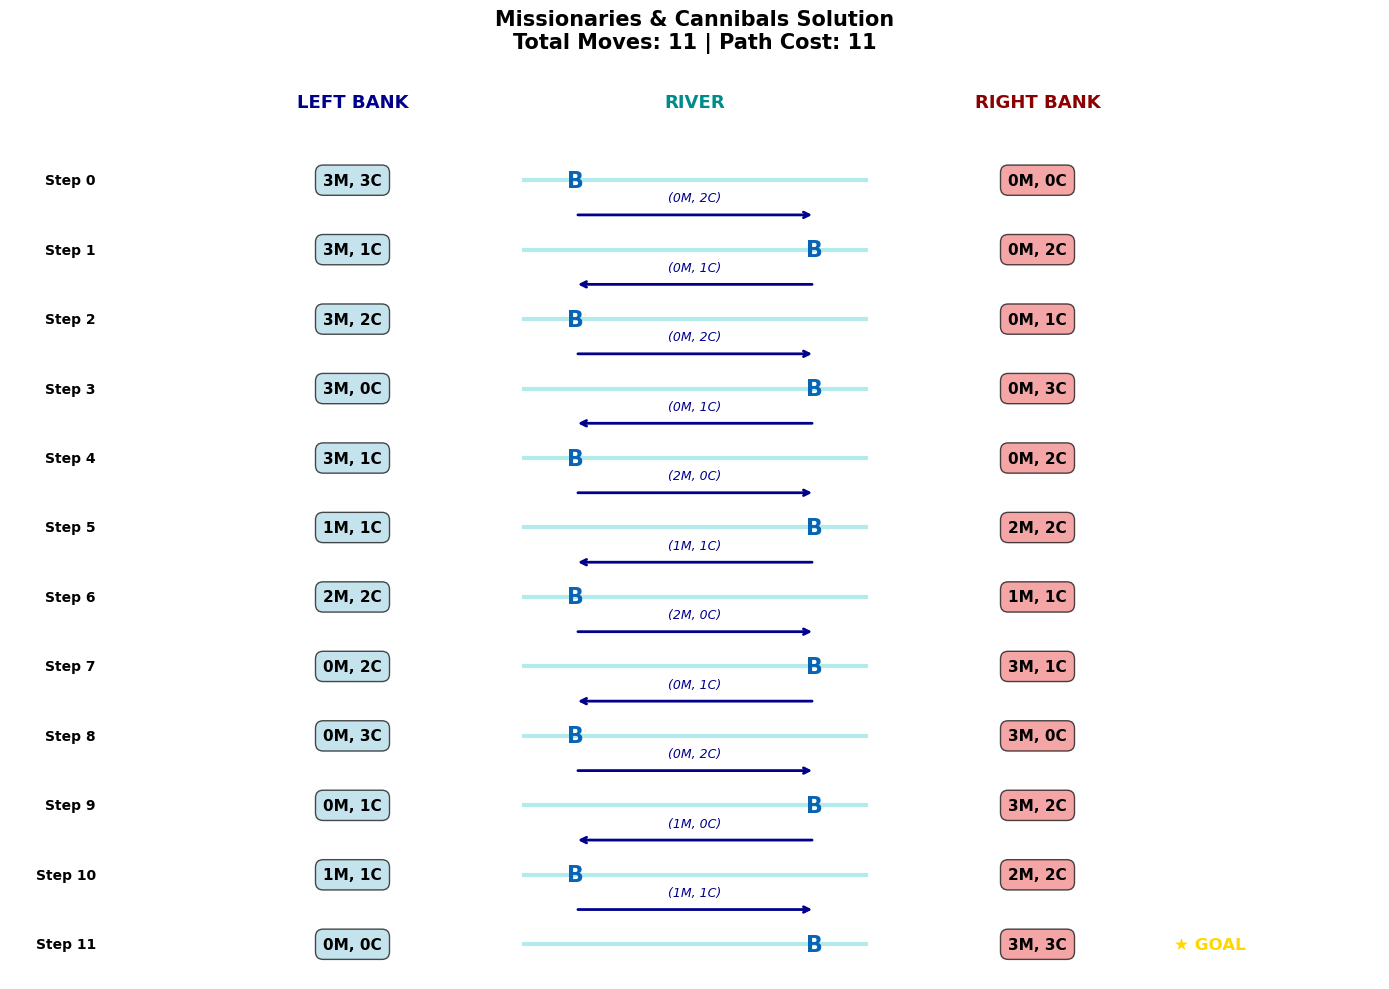

In [18]:
def visualize_missionary_solution(problem, solution, figsize=(14, 10)):
    """
    Visualize the missionaries and cannibals solution as a state diagram.
    
    Args:
        problem: MissionaryProblem instance
        solution: solution node from search
        figsize: figure size tuple
    """
    if not solution:
        print("No solution to visualize!")
        return
    
    path = path_states(solution)
    actions = path_actions(solution)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Calculate layout
    n_steps = len(path)
    step_height = 1.0
    
    # Colors
    missionary_color = '#4CAF50'  # Green
    cannibal_color = '#FF5722'    # Red
    boat_color = "#0864B5"        # Blue
    
    # Draw each state
    for i, state in enumerate(path):
        M_L, C_L, M_R, C_R, B = state
        y_pos = (n_steps - 1 - i) * step_height
        
        # Step number
        ax.text(-0.5, y_pos, f"Step {i}", ha='right', va='center', 
                fontsize=10, fontweight='bold')
        
        # Left bank
        left_text = f"{M_L}M, {C_L}C"
        ax.text(1, y_pos, left_text, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
                fontsize=11, fontweight='bold')
        
        # River
        ax.plot([2, 4], [y_pos, y_pos], 'c-', linewidth=3, alpha=0.3)
        
        # Boat position and movement
        boat_x = 2.3 if B == 'L' else 3.7
        ax.text(boat_x, y_pos, 'B' if B == 'R' else 'B', ha='center', va='center', 
                fontsize=16, color=boat_color, fontweight='bold')
        
        # Show action taken (except for initial state)
        if i > 0:
            m, c = actions[i-1]
            prev_state = path[i-1]
            action_text = f"({m}M, {c}C)"
            arrow = '→' if prev_state[4] == 'L' else '←'
            
            # Draw arrow and action label
            action_y = y_pos + step_height/2
            if prev_state[4] == 'L':
                ax.annotate('', xy=(3.7, action_y), xytext=(2.3, action_y),
                           arrowprops=dict(arrowstyle='->', lw=2, color='darkblue'))
                ax.text(3, action_y + 0.15, action_text, ha='center', va='bottom',
                       fontsize=9, style='italic', color='darkblue')
            else:
                ax.annotate('', xy=(2.3, action_y), xytext=(3.7, action_y),
                           arrowprops=dict(arrowstyle='->', lw=2, color='darkblue'))
                ax.text(3, action_y + 0.15, action_text, ha='center', va='bottom',
                       fontsize=9, style='italic', color='darkblue')
        
        # Right bank
        right_text = f"{M_R}M, {C_R}C"
        ax.text(5, y_pos, right_text, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.7),
                fontsize=11, fontweight='bold')
        
        # Highlight goal state
        if i == len(path) - 1:
            ax.text(5.8, y_pos, '★ GOAL', ha='left', va='center',
                   fontsize=12, fontweight='bold', color='gold')
    
    # Labels
    ax.text(1, (n_steps) * step_height, 'LEFT BANK', ha='center', va='bottom',
           fontsize=13, fontweight='bold', color='darkblue')
    ax.text(3, (n_steps) * step_height, 'RIVER', ha='center', va='bottom',
           fontsize=13, fontweight='bold', color='darkcyan')
    ax.text(5, (n_steps) * step_height, 'RIGHT BANK', ha='center', va='bottom',
           fontsize=13, fontweight='bold', color='darkred')
    
    # Title
    ax.set_title(f'Missionaries & Cannibals Solution\n'
                f'Total Moves: {len(actions)} | Path Cost: {solution.path_cost:.0f}',
                fontsize=15, fontweight='bold', pad=20)
    
    # Formatting
    ax.set_xlim(-1, 7)
    ax.set_ylim(-0.5, (n_steps) * step_height + 0.5)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize the solution
visualize_missionary_solution(missionary_problem, missionary_solution)